In [1]:
# =============================================================================
# Antibiotic Resistance Prediction using Proximity, Frequency, and G-score
# =============================================================================
# 
# This notebook trains and evaluates Random Forest classifiers on mutation-level
# features (mutation frequency, 3D structural proximity to known resistance-conferring
# mutations, 1D primary sequence proximity to known resistance-conferring mutations, and g-scores) to predict antibiotic resistance in Mycobacterium tuberculosis.
# It includes baseline modeling,combined modeling and predictions for uncertain mutations (Category 3).

In [24]:
## load dependencies
import pandas as pd
import numpy as np
import re
from evcouplings.compare import DistanceMap
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, classification_report,
                             accuracy_score,roc_auc_score, roc_curve, auc, ConfusionMatrixDisplay)
from scipy import stats
import os,json
import warnings
warnings.filterwarnings("ignore")

In [3]:
from utils import *

## data preprocessing

In [4]:
# ----------------------------
# STEP 1: Load and Inspect Dataset
# ----------------------------
final_df = pd.read_csv("../data/derived_features/all_proteins_freq_proximity_gscore.csv")
print("Unique genes:", np.unique(final_df['gene']))
print("Data shape:", final_df.shape)

Unique genes: ['Rv0678' 'atpE' 'ddn' 'embB' 'ethA' 'fgd1' 'gid' 'gyrA' 'gyrB' 'inhA'
 'katG' 'pepQ' 'pncA' 'rplC' 'rpoB' 'rpsL' 'tlyA']
Data shape: (4690, 16)


In [5]:
# STEP 2: Basic Preprocessing
# ----------------------------
# Separate Category 3 entries (uncertain mutations)
category_3_data = final_df[final_df['confidence'] == "3) Uncertain significance"]

# Retain only labeled data (non-Category 3) for supervised learning
label_data = final_df[final_df['confidence'] != "3) Uncertain significance"]

# Target conversion to binary
label_data['binary_confidence'] = label_data['confidence'].map({
    "1) Assoc w R": 0,
    "2) Assoc w R - Interim": 0,
    "4) Not assoc w R - Interim": 1,
    "5) Not assoc w R": 1
})

# Drop missing targets
label_data = label_data[label_data['binary_confidence'].notna()]

#some debugging steps
print(label_data['confidence'].value_counts())
print(np.unique(label_data['confidence']))
# Identify rows where the 'frequency' column is NaN
nan_frequency_rows = label_data[label_data['frequency'].isna()]

diverse_sample_mutation_table = label_data.groupby('frequency').first().reset_index()
diverse_sample_mutation_table.head()

confidence
2) Assoc w R - Interim        160
1) Assoc w R                  155
5) Not assoc w R               38
4) Not assoc w R - Interim     22
Name: count, dtype: int64
['1) Assoc w R' '2) Assoc w R - Interim' '4) Not assoc w R - Interim'
 '5) Not assoc w R']


/var/folders/90/7pfcyv8s59v1d678dnl3bgxw0000gq/T/ipykernel_69196/3132060444.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  label_data['binary_confidence'] = label_data['confidence'].map({


,frequency,drug,gene,variant,Present_R,Present_S,confidence,one_letter_mutation,phenotype,position,WHO_Adjusted_Position,Proximity_to_R_Conferring,Nearest_Mutation_Index,Proximity_to_R_Conferring_1D,Nearest_Mutation_Index_1D,G_score,binary_confidence
0,0.000000,RIF,rpoB,rpoB_G426S,0.0,1.0,2) Assoc w R - Interim,G426S,Resistant,426,432.0,1.335177,433.0,1.0,433.0,2.296259,0
1,0.010204,EMB,embB,embB_Q139H,1.0,97.0,5) Not assoc w R,Q139H,Susceptible,139,NaN,32.089950,74.0,65.0,74.0,-0.302846,1
2,0.013274,LEV,gyrB,gyrB_P94L,3.0,223.0,5) Not assoc w R,P94L,Susceptible,94,NaN,57.169795,501.0,367.0,461.0,-1.423563,1
3,0.018182,RIF,rpoB,rpoB_K944E,1.0,54.0,5) Not assoc w R,K944E,Susceptible,944,950.0,44.237799,449.0,453.0,497.0,-0.120555,1
4,0.020609,MXF,gyrA,gyrA_A384V,23.0,1093.0,5) Not assoc w R,A384V,Susceptible,384,NaN,39.790840,91.0,290.0,94.0,-0.177343,1


## run the baseline and combined models

In [14]:
feature_sets = {
    "Frequency": ['frequency'],
    "Proximity_3D": ['Proximity_to_R_Conferring'],
    "Proximity_1D": ['Proximity_to_R_Conferring_1D'],
    "G-score": ['G_score'],
    # "Frequency + Proximity": ['frequency', 'Proximity_to_R_Conferring'],
    # "Frequency + G-score": ['frequency', 'G_score'],
    # "Combined": ['frequency', 'Proximity_to_R_Conferring', 'G_score']
}



=== Running model for: Frequency ===
Confusion Matrix:
[[88  7]
 [ 0 18]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.93      0.96        95
           1       0.72      1.00      0.84        18

    accuracy                           0.94       113
   macro avg       0.86      0.96      0.90       113
weighted avg       0.96      0.94      0.94       113

Accuracy: 0.9380530973451328
AUC: {0: 0.9894736842105264, 1: 0.9894736842105263}
Precision: 0.9553982300884956
sensitivity: 0.9263157894736842
specificity 1.0


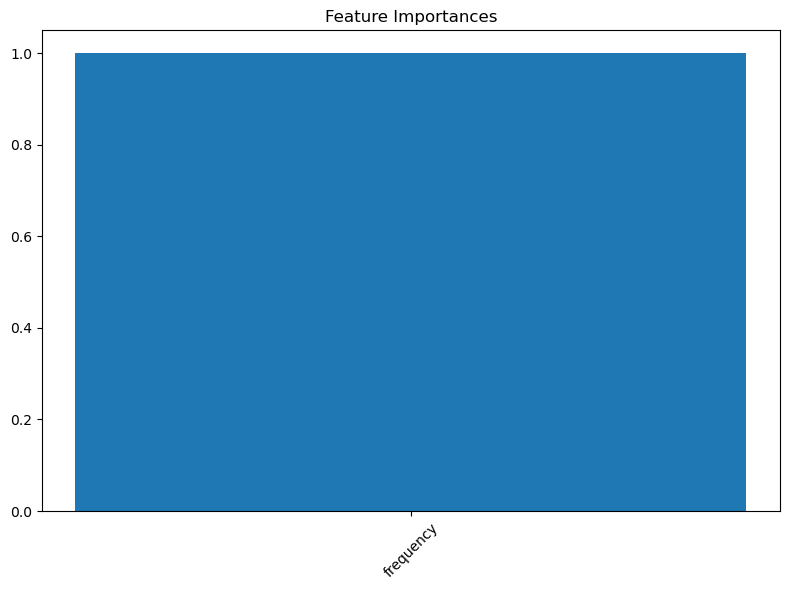


=== Running model for: Proximity_3D ===
Confusion Matrix:
[[95  0]
 [ 6 12]]
Classification Report:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97        95
           1       1.00      0.67      0.80        18

    accuracy                           0.95       113
   macro avg       0.97      0.83      0.88       113
weighted avg       0.95      0.95      0.94       113

Accuracy: 0.9469026548672567
AUC: {0: 0.860233918128655, 1: 0.8602339181286549}
Precision: 0.9500569525979147
sensitivity: 1.0
specificity 0.6666666666666666


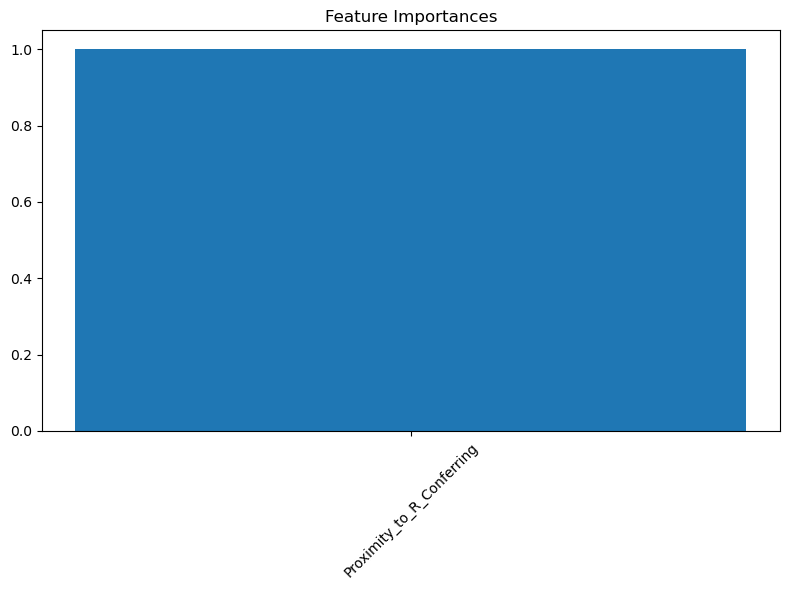


=== Running model for: Proximity_1D ===
Confusion Matrix:
[[95  0]
 [ 9  9]]
Classification Report:
              precision    recall  f1-score   support

           0       0.91      1.00      0.95        95
           1       1.00      0.50      0.67        18

    accuracy                           0.92       113
   macro avg       0.96      0.75      0.81       113
weighted avg       0.93      0.92      0.91       113

Accuracy: 0.9203539823008849
AUC: {0: 0.8833333333333333, 1: 0.8833333333333334}
Precision: 0.9272464261402313
sensitivity: 1.0
specificity 0.5


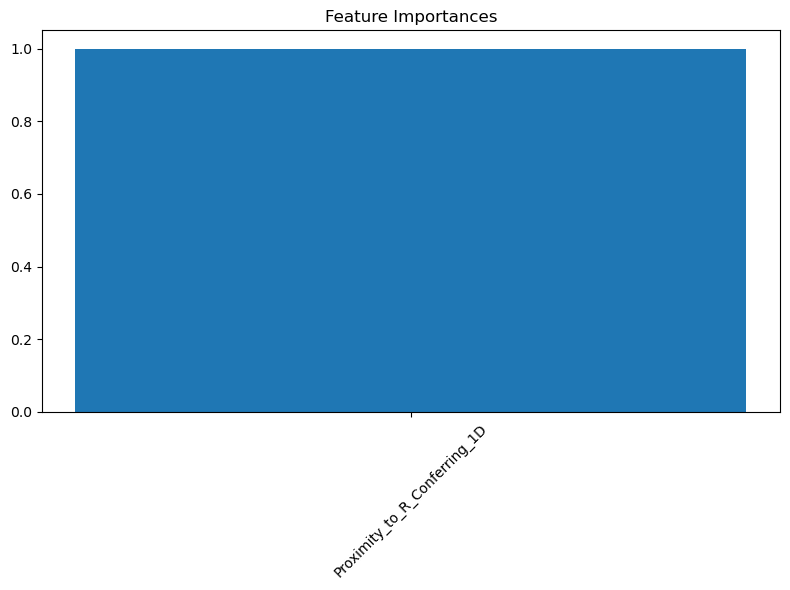


=== Running model for: G-score ===
Confusion Matrix:
[[87  8]
 [ 3 15]]
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.92      0.94        95
           1       0.65      0.83      0.73        18

    accuracy                           0.90       113
   macro avg       0.81      0.87      0.84       113
weighted avg       0.92      0.90      0.91       113

Accuracy: 0.9026548672566371
AUC: {0: 0.9084795321637427, 1: 0.9084795321637427}
Precision: 0.9165704758240348
sensitivity: 0.9157894736842105
specificity 0.8333333333333334


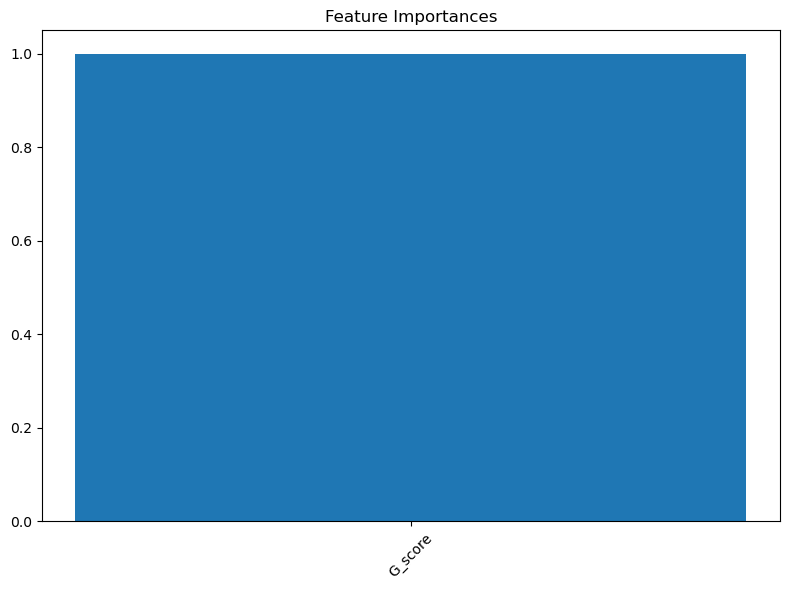

In [27]:
results = {}

def performance_evaluation(y_test, y_pred,y_prob):
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    precision = classification_report(y_test, y_pred, output_dict=True)['weighted avg']['precision'] #dataset is class imbalanced
    sensitivity = classification_report(y_test, y_pred, output_dict=True)['0']['recall']
    specificity= classification_report(y_test, y_pred, output_dict=True)['1']['recall']
    accuracy= accuracy_score(y_test, y_pred)

    # Create mapping from class label to index
    class_to_index = {cls: idx for idx, cls in enumerate(np.unique(y_test))}

    fpr, tpr, roc_auc = {}, {}, {}
    for cls in class_to_index:
        idx = class_to_index[cls]
        fpr[cls], tpr[cls], _ = roc_curve(y_test == cls, y_prob[:, idx])
        roc_auc[cls] = auc(fpr[cls], tpr[cls])
        
    #plot roc-auc curve     
    # plt.figure(figsize=(8, 6))
    # for cls in class_to_index:
    #     plt.plot(fpr[cls], tpr[cls], label=f"Class {cls} (AUC = {roc_auc[cls]:.2f})")
    # plt.plot([0, 1], [0, 1], 'k--')
    # plt.xlabel("False Positive Rate")
    # plt.ylabel("True Positive Rate")
    # plt.title("ROC Curve")
    # plt.legend()
    # plt.grid()
    # plt.show()
    return accuracy, roc_auc, precision, sensitivity, specificity

for label, numeric_columns in feature_sets.items():
    print(f"\n=== Running model for: {label} ===")

    # Step 3: Feature selection
    label_data[numeric_columns] = label_data[numeric_columns].fillna(0)
    
    # Step 4: Split
    X_train, X_test, y_train, y_test, train_indices, test_indices = data_split(label_data, numeric_columns)
    
    # Step 5: Train and evaluate
    trained_rf, y_pred_test, y_prob_test = model_training(X_train, y_train, X_test)
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred_test))
    accuracy, roc_auc, precision, sensitivity, specificity = performance_evaluation(y_test, y_pred_test, y_prob_test)
    print("Accuracy:", accuracy)
    print("AUC:", roc_auc)
    print("Precision:", precision)
    print("sensitivity:", sensitivity)
    print("specificity", specificity)

    # Step 6: Feature importance
    feature_importances = plot_feature_importance(trained_rf, numeric_columns)

    # Step 7: Category 3 prediction
    (
        misclassified_original_indices,
        misclassified_samples,
        confidence_0_count,
        confidence_0_percentage,
        confidence_1_count,
        confidence_1_percentage
    ) = predict_category_3(
        category_3_data,
        trained_rf,
        final_df,
        numeric_columns,
        y_test,
        y_pred_test,
        test_indices
    )

    # Store all results
    results[label] = {
        "features": numeric_columns,
        "accuracy": accuracy,
        "precision": precision,
        "roc_auc": roc_auc,
        "feature_importance": feature_importances,
        "misclassified_indices": misclassified_original_indices,
        "misclassified_samples": misclassified_samples,
        "sensitivity": sensitivity,
        "specificity": specificity,
        "category_3_predictions": {
            "resistant_count": confidence_0_count,
            "susceptible_count": confidence_1_count,
            "resistant_percentage": confidence_0_percentage,
            "susceptible_percentage": confidence_1_percentage
        }
    }


In [28]:
def find_invalid_keys(obj, path="root"):
    if isinstance(obj, dict):
        for k, v in obj.items():
            if not isinstance(k, (str, int, float, bool, type(None))):
                print(f"[Invalid Key] Path: {path} → Key: {k} (type: {type(k).__name__})")
            find_invalid_keys(v, path=f"{path}['{k}']")
    elif isinstance(obj, list):
        for i, item in enumerate(obj):
            find_invalid_keys(item, path=f"{path}[{i}]")


# Check before saving
find_invalid_keys(results)

def convert_keys_to_str(obj):
    if isinstance(obj, dict):
        return {str(k): convert_keys_to_str(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [convert_keys_to_str(i) for i in obj]
    else:
        return obj
cleaned_results = convert_keys_to_str(results)

[Invalid Key] Path: root['Frequency']['roc_auc'] → Key: 0 (type: int64)
[Invalid Key] Path: root['Frequency']['roc_auc'] → Key: 1 (type: int64)
[Invalid Key] Path: root['Proximity_3D']['roc_auc'] → Key: 0 (type: int64)
[Invalid Key] Path: root['Proximity_3D']['roc_auc'] → Key: 1 (type: int64)
[Invalid Key] Path: root['Proximity_1D']['roc_auc'] → Key: 0 (type: int64)
[Invalid Key] Path: root['Proximity_1D']['roc_auc'] → Key: 1 (type: int64)
[Invalid Key] Path: root['G-score']['roc_auc'] → Key: 0 (type: int64)
[Invalid Key] Path: root['G-score']['roc_auc'] → Key: 1 (type: int64)


In [9]:
with open("../results/baseline_combined_results.json", "w") as f:
    for label in cleaned_results:
        for key in cleaned_results[label]:
            if not isinstance(key, (str, int, float, bool, type(None))):
                print("Invalid key type:", key, type(key))
    json.dump(cleaned_results, f, indent=4, default=str)

print("\nAll model combinations evaluated and saved.")


All model combinations evaluated and saved.


In [34]:
def generate_markdown_table(results_dict):
    table_md = "| Model | AUC | Sens | Spec | \n"
    table_md += "|------|------|------|------|\n"

    for model_name, metrics in results_dict.items():
        acc = f"{metrics.get('accuracy', 0) * 100:.1f}%"
        prec = f"{metrics.get('precision', 0) * 100:.1f}%"

        roc_auc = metrics.get('roc_auc', None)
        if isinstance(roc_auc, dict):
            # Average over classes
            auc_val = np.mean(list(roc_auc.values()))
        else:
            auc_val = roc_auc

        auc_str = f"{auc_val * 100:.1f}%" if auc_val is not None else "N/A"

        sens = f"{metrics.get('sensitivity', 0) * 100:.1f}%"
        spec = f"{metrics.get('specificity', 0) * 100:.1f}%"

        table_md += f"| {model_name} | {auc_str} | {sens} | {spec} | \n"

    return table_md


In [35]:
markdown_output = generate_markdown_table(cleaned_results)
print(markdown_output)

| Model | AUC | Sens | Spec | 
|------|------|------|------|
| Frequency | 98.9% | 92.6% | 100.0% | 
| Proximity_3D | 86.0% | 100.0% | 66.7% | 
| Proximity_1D | 88.3% | 100.0% | 50.0% | 
| G-score | 90.8% | 91.6% | 83.3% | 

